# Analytic solutions for pseudo particle diagrams of one fermion and a two-pole hybridization

This is a continuation of one_fermion_analytical_solutions.ipynb where we consider a slightly more complicated hybridization function: one that has two poles. We recall the following nice feature of one-fermion calculations: creation and annihilation operators must appear in an alternating sequence in order to give a non-zero result.

In [1]:
import sympy as sp

In [2]:
t, t1, t2, t3, t4 = sp.symbols(r'\tau \tau_1 \tau_2 \tau_3 \tau_4', positive=True)
b, w, w1, w2 = sp.symbols(r'\beta \omega \omega_1 \omega_2', nonzero=True)

## Fermi kernel

$$
K(\tau, \omega) = - \frac{e^{-\omega \tau}}{1 + e^{-\beta \omega}}
$$

for $\tau \in [0, \beta]$ the case of $-\beta < \tau < 0$ is given by the antiperiodic property $K(-\tau, \omega) \equiv - K(\beta - \tau, \omega) = - K(\tau, -\omega)$.

We will also make use of $K(\tau, \omega) = K(0, \omega) e^{-\omega \tau}$ in the integral relations below.

In [3]:
K = lambda t, w : -sp.exp(-w*t)/(1 + sp.exp(-b*w))
K(t, w)

-exp(-\omega*\tau)/(1 + exp(-\beta*\omega))

## Atomic kernel-convolution identity

Before combining two poles inside a diagram, we check the single building
block that all the multi-pole integrals below rely on: the convolution of
two *distinct* single-exponential kernels, using only
$K(\tau,\omega) = K(0,\omega) e^{-\omega\tau}$:

$$
\int_0^\tau d\tau' \, K(\tau - \tau', \omega) K(\tau', \omega')
=
\frac{K(0,\omega) K(\tau,\omega') - K(\tau,\omega) K(0,\omega')}{\omega - \omega'}
\qquad (\omega \neq \omega')
$$

with the degenerate limit

$$
\int_0^\tau d\tau' \, K(\tau - \tau', \omega) K(\tau', \omega)
=
\tau \, K(0,\omega) K(\tau,\omega).
$$

This is cheap because it involves only *one* pair of independent
frequencies $\omega,\omega'$ — no sum over poles is expanded before
integrating, which is exactly what made the third-order integral below
hang once $\Delta$ became a two-term sum. Once trusted, this identity is
the reusable building block for assembling multi-pole diagrams without
ever asking `sp.integrate` to swallow an already-expanded sum-of-poles
integrand.

In [4]:
tp = sp.Symbol(r"\tau'", positive=True)
wp = sp.Symbol(r"\omega'", nonzero=True)

conv_lhs = sp.integrate(K(t - tp, w) * K(tp, wp), (tp, 0, t))
conv_rhs = (K(0, w)*K(t, wp) - K(t, w)*K(0, wp)) / (w - wp)

conv_diff = sp.simplify(conv_lhs - conv_rhs)
conv_diff

Piecewise((0, Ne(\omega, \omega')), ((\tau*(\omega - \omega')*exp(\beta*\omega + \beta*\omega' - \omega'*\tau + \tau*(\omega + \omega')) - exp(\beta*\omega + \beta*\omega' + \omega*\tau) + exp(\beta*\omega + \beta*\omega' + \omega'*\tau))*exp(-\tau*(\omega + \omega'))/((\omega - \omega')*(exp(\beta*\omega) + 1)*(exp(\beta*\omega') + 1)), True))

In [5]:
# conv_diff above is a Piecewise that is exactly 0 on the omega != omega' branch;
# as an independent check, confirm the two sides agree numerically away from omega = omega'
import random

random.seed(0)
max_err = 0
for _ in range(5):
    subs = {b: random.uniform(0.5, 3), w: random.uniform(-2, 2),
            wp: random.uniform(-2, 2), t: random.uniform(0.1, 2)}
    lv = complex(conv_lhs.subs(subs).evalf())
    rv = complex(conv_rhs.subs(subs).evalf())
    max_err = max(max_err, abs(lv - rv))

max_err

0

In [6]:
# Degenerate case omega = omega': recompute the integral directly (do not
# substitute wp -> w into conv_rhs, since that ratio is 0/0 there)
conv_lhs_deg = sp.integrate(K(t - tp, w) * K(tp, w), (tp, 0, t))
conv_rhs_deg = t * K(0, w) * K(t, w)

conv_diff_deg = sp.simplify(conv_lhs_deg - conv_rhs_deg)
conv_diff_deg

0

In [7]:
# Consistency check tying the two branches together: the omega' -> omega
# limit of the generic closed form must reproduce the degenerate closed form
conv_limit_check = sp.simplify(sp.limit(conv_rhs, wp, w) - conv_rhs_deg)
conv_limit_check

0

## Hybridization function

$$
\Delta(\tau) = K(\tau, \omega_1) + 2K(\tau, \omega_2).
$$

In [8]:
D = lambda t : K(t, w1) + 2 * K(t, w2)
# rho = lambda w : (2 / sp.pi) * sp.sqrt(1 - w * w)
# D = lambda t : sp.integrate(K(t, w) * rho(w), (w, -sp.oo, sp.oo))
D(t)

-2*exp(-\omega_2*\tau)/(1 + exp(-\beta*\omega_2)) - exp(-\omega_1*\tau)/(1 + exp(-\beta*\omega_1))

In [9]:
Dr = lambda t : -K(t, -w1) - 2 * K(t, -w2)
# Dr = lambda t : sp.integrate(-K(t, -w) * rho(w), (w, -sp.oo, sp.oo))
Dr(t)

2*exp(\omega_2*\tau)/(exp(\beta*\omega_2) + 1) + exp(\omega_1*\tau)/(exp(\beta*\omega_1) + 1)

## Pseudo particle Green's function

$$
G(\tau) = - e^{-\alpha \tau}
$$

with $\alpha = \ln(2) / \beta$, such that $G(\beta) = - \frac{1}{2}$.

Inserting $\alpha$ gives

$$
G(\tau) = - 2^{-\tau/\beta}
$$

In [10]:
G = -sp.exp(-sp.ln(2) / b * t).simplify()
G

-1/2**(\tau/\beta)

Note that this propagator obeys the chain relation (with odd number of terms)

$$
G(\tau - \tau_1)G(\tau_1 - \tau_2) \dots G(\tau_{2n-1} - \tau_{2n})G(\tau_{2n} - 0)
= G(\tau)
$$

In [11]:
Gprod = G.subs(t, t - t1)*G.subs(t, t1 - t2) * G.subs(t, t2 - 0)
Gprod

-1/(2**(\tau_2/\beta)*2**((\tau - \tau_1)/\beta)*2**((\tau_1 - \tau_2)/\beta))

In [12]:
Gprod = Gprod.simplify()
Gprod

-1/2**(\tau/\beta)

In [13]:
Gprod == G

True

## First order self-energy diagrams

$$
\Sigma_{0,0}(\tau) = -\Delta(-\tau) G(\tau) = (K(\tau, -\omega_1) + 2 K(\tau, -\omega_2)) G(\tau)
$$

$$
\Sigma_{1, 1}(\tau) = \Delta(\tau) G(\tau) = (K(\tau, -\omega_1) + 2 K(\tau, -\omega_2)) G(\tau)
$$

In [14]:
Sigma_01_00 = -Dr(t) * G
Sigma_01_00

-(-2*exp(\omega_2*\tau)/(exp(\beta*\omega_2) + 1) - exp(\omega_1*\tau)/(exp(\beta*\omega_1) + 1))/2**(\tau/\beta)

In [15]:
Sigma_01_11 = D(t) * G 
Sigma_01_11

-(-2*exp(-\omega_2*\tau)/(1 + exp(-\beta*\omega_2)) - exp(-\omega_1*\tau)/(1 + exp(-\beta*\omega_1)))/2**(\tau/\beta)

## Regression check: two poles merging into one

Before trusting anything built on top of the two-pole $\Delta$, check the
$P \to 1$ limit: if the two poles coincide, $\omega_2 \to \omega_1$, the
hybridization collapses to a single (rescaled) pole,

$$
\Delta(\tau) \big|_{\omega_2 \to \omega_1} = K(\tau,\omega_1) + 2K(\tau,\omega_1) = 3K(\tau,\omega_1),
$$

i.e. exactly the single-pole $\Delta(\tau) = K(\tau,\omega)$ used in
`one_fermion_analytical_solutions.ipynb`, scaled by the combined weight
$1+2=3$. Since the first-order self-energy is linear in $\Delta$, the
merged two-pole result should equal $3\times$ the corresponding
single-pole result. This is a cheap way to catch sign/combinatorial
errors in the two-pole bookkeeping before they propagate into the (much
more expensive) higher-order diagrams.

In [16]:
# D, Dr should reduce to 3x the single-pole kernel at omega_2 -> omega_1
D_merge_diff = sp.simplify(D(t).subs(w2, w1) - 3*K(t, w1))
Dr_merge_diff = sp.simplify(Dr(t).subs(w2, w1) - 3*(-K(t, -w1)))
D_merge_diff, Dr_merge_diff

(0, 0)

In [17]:
# single-pole (weight 1) reference self-energies, same convention as
# one_fermion_analytical_solutions.ipynb: Delta(t) = K(t, w1), Delta_r(t) = -K(t, -w1)
Sigma_00_single = K(t, -w1) * G
Sigma_11_single = K(t, w1) * G

Sigma_00_merge_diff = sp.simplify(Sigma_01_00.subs(w2, w1) - 3*Sigma_00_single)
Sigma_11_merge_diff = sp.simplify(Sigma_01_11.subs(w2, w1) - 3*Sigma_11_single)
Sigma_00_merge_diff, Sigma_11_merge_diff

(0, 0)

## Second order self-energy diagrams

There are no non-zero diagrams since the second order diagram can not accomodate an alternating sequence of creation and annihilation operators.

## Third order self-energy diagrams

$$
\Sigma_{0,0}(\tau) =
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4
$$
$$
\Delta(\tau_3 - \tau) \Delta(\tau_1 - \tau_4) \Delta(0 - \tau_2)
$$
$$
G(\tau - \tau_1)G(\tau_1 - \tau_2)G(\tau_2 - \tau_3)
G(\tau_3 - \tau_4)G(\tau_4 - 0)
$$

$$
=
e^{-\alpha \tau}
\int_0^\tau d\tau_1 \int_0^{\tau_1} d\tau_2 
\int_0^{\tau_2} d\tau_3 \int_0^{\tau_3} d\tau_4 \,
\Delta(\tau_3 - \tau) \Delta(\tau_1 - \tau_4) \Delta(0 - \tau_2)
$$

### Deriving the closed form: per-pole line integrals, with deterministic branch selection

*(Correction: an earlier version of this cell "fixed" the hang below by speeding up the wrong formula —
its result passed an internal merge-consistency check but did **not** match the third-order $\Sigma_{0,0}$
in `one_fermion_analytical_solutions.ipynb` (cell 21), which is itself validated against the production
C++ backbone test. That reference derivation is used below instead.)*

From the reference notebook (cell 18), with a single pole $\omega$,
$$
\Sigma_{0,0}(\tau) = e^{-\alpha\tau}\!\int_0^\tau\!\!\int_0^{\tau_1}\!\!\int_0^{\tau_2}\!\!\int_0^{\tau_3}
K(\tau-\tau_3,-\omega)\,K(\tau_1-\tau_4,\omega)\,K(\tau_2,-\omega)\;d\tau_4\,d\tau_3\,d\tau_2\,d\tau_1.
$$
Call these three factors Line A, B, C. For a two-pole $\Delta$, each line independently picks up a
pole $\omega_1$ (weight 1) or $\omega_2$ (weight 2), giving $2^3=8$ combinations
$(\omega_a,\omega_b,\omega_c)\in\{\omega_1,\omega_2\}^3$ to sum with coefficient products — the same
symbolic-once/pole-sum strategy as before, but here we substitute $\omega_1,\omega_2$ directly (rather
than introducing separate generic dummy symbols) since there are only ever two possible pole values.

Three subtleties, found by comparing against brute-force quadrature term by term:
- Nested `sp.integrate` on this pattern hits an internal sympy bug (`ZeroDivisionError`) unless the
  integrand's exponent difference is known not to vanish, which happens whenever two of the three lines
  are assigned the same pole (expected — two independent hybridization insertions can legitimately land
  on the same discrete pole).
- Some assignments produce a `Piecewise` result partway through (sympy can't rule out a *second*, less
  obvious resonance — $\omega_1=2\omega_2$ or $\omega_2=2\omega_1$ — appearing in an intermediate step),
  and that `Piecewise` must be collapsed to its correct branch before it is fed into the next
  `sp.integrate` call, or the final answer is silently wrong.
- Sympy's usual tool for this, `sp.refine` with an `assuming`/`Q.ne(...)` context, does give the correct
  branch, but calls into sympy's general assumption/SAT solver, which turned out to crash occasionally
  with an internal `IndexError` (nondeterministically, seemingly hash-seed dependent) when run inside
  this notebook's kernel. Instead we select the correct `Piecewise` branch deterministically by
  evaluating each branch's condition at a fixed numeric probe point representative of our (always
  non-resonant) poles — simple, robust, and avoids sympy's assumption solver entirely.

In [18]:
# A fixed numeric point representative of our (always non-resonant) poles, used only to pick out
# the correct branch of any intermediate Piecewise -- the returned expression stays symbolic in w1, w2.
_probe = {w1: sp.Rational(53, 100), w2: sp.Rational(-131, 100)}

def resolve(expr):
    expr = sp.cancel(expr)
    if isinstance(expr, sp.Piecewise):
        for branch_expr, cond in expr.args:
            if cond == True or bool(cond.subs(_probe)):
                return sp.cancel(branch_expr)
        raise ValueError(f"no Piecewise branch matched the probe point: {expr}")
    return expr

def line_integral_00(pa, pb, pc):
    # Line A = K(tau-tau3,-pa), Line B = K(tau1-tau4,pb), Line C = K(tau2,-pc)
    I4 = resolve(sp.integrate(sp.exp(+pb*t4), (t4, 0, t3)))
    I3 = resolve(sp.integrate(sp.exp(-pa*t3) * I4, (t3, 0, t2)))
    I2 = resolve(sp.integrate(sp.exp(+pc*t2) * I3, (t2, 0, t1)))
    I1 = resolve(sp.integrate(sp.exp(-pb*t1) * I2, (t1, 0, t)))
    return resolve(G * K(0,-pa) * K(0,pb) * K(0,-pc) * sp.exp(pa*t) * I1)

In [19]:
poles = [(w1, 1), (w2, 2)]

Sigma_031425_00 = 0
for pa, ca in poles:
    for pb, cb in poles:
        for pc, cc in poles:
            Sigma_031425_00 += ca * cb * cc * line_integral_00(pa, pb, pc)
Sigma_031425_00 = sp.cancel(Sigma_031425_00)

### Regression check: two poles merging into one

As before, if $\omega_2 \to \omega_1$ the combined weight per line is $1+2=3$, so the merged result
should approach $3^3=27$ times the single-pole value. `Sigma_031425_00` was built assuming
$\omega_1\neq\omega_2$ internally, so substituting $\omega_2=\omega_1$ directly hits the same kind of
removable-singularity `nan` seen in the atomic-identity section — instead we check the limit
numerically, evaluating at $\omega_2$ approaching $\omega_1$.

In [20]:
Sigma_00_single = line_integral_00(w1, w1, w1)

_subs_diag = {b: 1.7, w1: 0.53, t: 0.9}
single_val = complex(Sigma_00_single.subs(_subs_diag).evalf())

merge_ratios = []
for eps in [1e-2, 1e-3, 1e-4]:
    val = complex(Sigma_031425_00.subs({**_subs_diag, w2: 0.53 + eps}).evalf())
    merge_ratios.append(val / (27 * single_val))
merge_ratios  # should approach 1 as eps -> 0

[(0.9908614283966222+0j), (0.9990861693974956+0j), (0.9998854498392192+0j)]

### Independent numerical cross-check

As a final, independent check that the closed form is correct (not just internally consistent),
evaluate `Sigma_031425_00` numerically at a concrete, resonance-free parameter point, and separately
evaluate the *original* nested integral directly — using the true two-pole diagram formula
$K(\tau-\tau_3,-\omega)K(\tau_1-\tau_4,\omega)K(\tau_2,-\omega)$ with $\omega \to$ the two-pole sum,
no decomposition at all — via brute-force floating-point nested quadrature.

In [21]:
subs_num = {b: 2.3, w1: 0.6, w2: -0.9, t: 0.9}
Sigma_031425_00_numeric = complex(Sigma_031425_00.subs(subs_num).evalf())
Sigma_031425_00_numeric

(0.037780425867333205+0j)

In [22]:
from scipy import integrate as spintegrate
import numpy as np

beta_n, om1_n, om2_n, tau_n = 2.3, 0.6, -0.9, 0.9

def K_num(tt, ww):
    return -np.exp(-ww*tt) / (1 + np.exp(-beta_n*ww))

def Ktwopole_num(x, sign):
    # two-pole generalization of K(x, sign*omega): weight 1 at omega1, weight 2 at omega2
    return K_num(x, sign*om1_n) + 2*K_num(x, sign*om2_n)

def G_num(tt):
    return -np.exp(-np.log(2)/beta_n*tt)

def integrand(t4v, t3v, t2v, t1v):
    return Ktwopole_num(tau_n - t3v, -1) * Ktwopole_num(t1v - t4v, +1) * Ktwopole_num(t2v, -1)

def inner4(t1v, t2v, t3v):
    val, _ = spintegrate.quad(integrand, 0, t3v, args=(t3v, t2v, t1v), limit=80)
    return val

def inner3(t1v, t2v):
    val, _ = spintegrate.quad(lambda t3v: inner4(t1v, t2v, t3v), 0, t2v, limit=80)
    return val

def inner2(t1v):
    val, _ = spintegrate.quad(lambda t2v: inner3(t1v, t2v), 0, t1v, limit=80)
    return val

I1_num, _ = spintegrate.quad(inner2, 0, tau_n, limit=80)
Sigma_031425_00_bruteforce = G_num(tau_n) * I1_num

Sigma_031425_00_numeric, Sigma_031425_00_bruteforce, abs(Sigma_031425_00_numeric - Sigma_031425_00_bruteforce)

((0.037780425867333205+0j),
 np.float64(0.03778042586733481),
 1.6028844918025698e-15)

**Caveat — resonance poles in the closed form.** `Sigma_031425_00`, viewed as a function of
$\omega_1,\omega_2$ for fixed generic $\tau,\beta$, has genuine poles wherever $\omega_1=\omega_2$,
or $\omega_1=2\omega_2$, or $\omega_2=2\omega_1$ (the two resonance types found while deriving it above).
`sp.lambdify`/`evalf` will produce `zoo`/`nan` if the chosen $(\omega_1,\omega_2)$ hits one of these.
The values used above and below ($\omega_1=0.6,\ \omega_2=-0.9$) were checked against this list.

Switching the direction of all hybridization functions gives the $\Sigma_{1,1}$ diagram. Tracing
through cells 18-21 of the reference notebook shows this is **not** simply $\omega\to-\omega$
substituted into the closed form (that naive guess was checked and is wrong); rather, each line's
role flips independently, using $K(x,+\omega)$ instead of $K(x,-\omega)$ (or vice versa) at the *same*
arguments, with no overall sign:
$$
\Sigma_{1,1}(\tau) = e^{-\alpha\tau}\!\int_0^\tau\!\!\int_0^{\tau_1}\!\!\int_0^{\tau_2}\!\!\int_0^{\tau_3}
K(\tau-\tau_3,+\omega)\,K(\tau_1-\tau_4,-\omega)\,K(\tau_2,+\omega)\;d\tau_4\,d\tau_3\,d\tau_2\,d\tau_1,
$$
i.e. Line A: $-\omega\to+\omega$, Line B: $+\omega\to-\omega$, Line C: $-\omega\to+\omega$, verified
below to reduce exactly to the known single-pole $\Sigma_{1,1}$ (this section's original form, before
the two-pole generalization) at $\omega_a=\omega_b=\omega_c=\omega$.

In [23]:
def line_integral_11(pa, pb, pc):
    # Line A = K(tau-tau3,+pa), Line B = K(tau1-tau4,-pb), Line C = K(tau2,+pc)
    I4 = resolve(sp.integrate(sp.exp(-pb*t4), (t4, 0, t3)))
    I3 = resolve(sp.integrate(sp.exp(+pa*t3) * I4, (t3, 0, t2)))
    I2 = resolve(sp.integrate(sp.exp(-pc*t2) * I3, (t2, 0, t1)))
    I1 = resolve(sp.integrate(sp.exp(+pb*t1) * I2, (t1, 0, t)))
    return resolve(G * K(0,pa) * K(0,-pb) * K(0,pc) * sp.exp(-pa*t) * I1)

# sanity: at a single shared pole, this must reduce to this section's original (pre-two-pole) formula
I4_ref = sp.integrate(sp.exp(-w*t4), (t4, 0, t3))
I3_ref = sp.integrate(sp.exp(+w*t3) * I4_ref, (t3, 0, t2))
I2_ref = sp.integrate(sp.exp(-w*t2) * I3_ref, (t2, 0, t1)).simplify()
I1_ref = sp.integrate(sp.exp(+w*t1) * I2_ref, (t1, 0, t))
Sigma_031425_11_single_pole_ref = G * K(0, w)**2 * K(0, -w) * sp.exp(-w*t) * I1_ref

single_pole_check = sp.simplify(line_integral_11(w1, w1, w1).subs(w1, w) - Sigma_031425_11_single_pole_ref)
single_pole_check

0

In [24]:
poles = [(w1, 1), (w2, 2)]

Sigma_031425_11 = 0
for pa, ca in poles:
    for pb, cb in poles:
        for pc, cc in poles:
            Sigma_031425_11 += ca * cb * cc * line_integral_11(pa, pb, pc)
Sigma_031425_11 = sp.cancel(Sigma_031425_11)

### Regression check and independent cross-check for $\Sigma_{1,1}$

Same two checks as for $\Sigma_{0,0}$: the $\omega_2\to\omega_1$ merge limit (numeric, for the same
removable-singularity reason as above) should approach $27\times$ the single-pole value, and the
closed form should match brute-force quadrature of the true (undecomposed) diagram integral.

In [25]:
Sigma_11_single = line_integral_11(w1, w1, w1)
single11_val = complex(Sigma_11_single.subs(_subs_diag).evalf())

merge11_ratios = []
for eps in [1e-2, 1e-3, 1e-4]:
    val = complex(Sigma_031425_11.subs({**_subs_diag, w2: 0.53 + eps}).evalf())
    merge11_ratios.append(val / (27 * single11_val))
merge11_ratios  # should approach 1 as eps -> 0

[(0.9949635464135953+0j), (0.9995008318808273+0j), (0.9999906145111068+0j)]

In [26]:
Sigma_031425_11_numeric = complex(Sigma_031425_11.subs(subs_num).evalf())

def integrand_11(t4v, t3v, t2v, t1v):
    return Ktwopole_num(tau_n - t3v, +1) * Ktwopole_num(t1v - t4v, -1) * Ktwopole_num(t2v, +1)

def inner4_11(t1v, t2v, t3v):
    val, _ = spintegrate.quad(integrand_11, 0, t3v, args=(t3v, t2v, t1v), limit=80)
    return val

def inner3_11(t1v, t2v):
    val, _ = spintegrate.quad(lambda t3v: inner4_11(t1v, t2v, t3v), 0, t2v, limit=80)
    return val

def inner2_11(t1v):
    val, _ = spintegrate.quad(lambda t2v: inner3_11(t1v, t2v), 0, t1v, limit=80)
    return val

I1_num_11, _ = spintegrate.quad(inner2_11, 0, tau_n, limit=80)
Sigma_031425_11_bruteforce = G_num(tau_n) * I1_num_11

Sigma_031425_11_numeric, Sigma_031425_11_bruteforce, abs(Sigma_031425_11_numeric - Sigma_031425_11_bruteforce)

((0.026107544730993307+0j),
 np.float64(0.0261075447309936),
 2.914335439641036e-16)

## Third order single particle Green's function diagram

As in the reference notebook, the single particle Green's function $g(\tau) = -\langle \mathcal{T} c(\tau) c^\dagger(0) \rangle$ sets the operator at the $\tau = 0$ vertex to be $c^\dagger$, so only the empty state $|0\rangle$ contributes to the outer trace, leaving a single non-zero third order diagram (topology $[(0,3), (1,4), (2,5)]$):

$$
g_3(\tau) =
\int_\tau^\beta d\tau_1 \int_\tau^{\tau_1} d\tau_2
\int_0^\tau d\tau_3 \int_0^{\tau_3} d\tau_4
$$
$$
\Delta(\tau_3 - \tau_1) \Delta(\tau_2 - \tau_4)
$$
$$
G(\beta - \tau_1)G(\tau_1 - \tau_2)G(\tau_2 - \tau)
G(\tau - \tau_3)G(\tau_3 - \tau_4)G(\tau_4 - 0)
$$

### Generalizing to two poles

The reference notebook (cell 27) reduces the single-pole diagram to

$$
g_3(\tau) = -G(\beta) K(0,\omega) K(0,-\omega)
\left[\int_\tau^\beta d\tau_1 \int_\tau^{\tau_1} d\tau_2\, e^{\omega(\tau_1-\tau_2)}\right]
\left[\int_0^\tau d\tau_3 \int_0^{\tau_3} d\tau_4\, e^{\omega(-\tau_3+\tau_4)}\right].
$$

With a two-pole $\Delta$, the two hybridization insertions $\Delta(\tau_3-\tau_1)$ and $\Delta(\tau_2-\tau_4)$ each independently
pick up a pole $\omega_1$ (weight 1) or $\omega_2$ (weight 2), giving $2\times2=4$ combinations $(p_a, p_b)\in\{\omega_1,\omega_2\}^2$
to sum with coefficient products — the same per-line pole-sum strategy used above for the third order self-energy.

Unlike the self-energy case, the two lines here do *not* share a single integration variable pair, so plugging in two
independent poles $p_a \neq p_b$ changes what factors out of the nested integral: the left double integral becomes
$\int_\tau^\beta d\tau_1\int_\tau^{\tau_1}d\tau_2\, e^{p_a\tau_1 - p_b\tau_2}$ and the right one
$\int_0^\tau d\tau_3\int_0^{\tau_3}d\tau_4\, e^{-p_a\tau_3 + p_b\tau_4}$ (recovering the single-pole forms above when $p_a=p_b$).
Tracking the coefficients through the same derivation gives

$$
g_3^{(p_a,p_b)}(\tau) = K(0,-p_a)\,K(0,p_b)\,
\left[\int_\tau^\beta d\tau_1 \int_\tau^{\tau_1} d\tau_2\, e^{p_a\tau_1 - p_b\tau_2}\right]
\left[\int_0^\tau d\tau_3 \int_0^{\tau_3} d\tau_4\, e^{-p_a\tau_3 + p_b\tau_4}\right] \Big/ 2,
$$

using $-G(\beta) = 1/2$ as before. This was checked to reduce exactly to the reference single-pole formula at $p_a=p_b=\omega$
(via the degenerate branch of the nested integral, same as the `Ne(\omega_1-\omega_2, 0)` Piecewise seen earlier), and independently
against brute-force quadrature of the original diagram below. As with the self-energy lines, we reuse `resolve` to pick the
correct Piecewise branch deterministically.

In [27]:
def line_integral_spgf(pa, pb):
    # Left factor: Delta(tau3-tau1) line, pole pa. Right factor: Delta(tau2-tau4) line, pole pb.
    IL = resolve(sp.integrate(sp.exp(pa*t1 - pb*t2), (t2, t, t1), (t1, t, b)))
    IR = resolve(sp.integrate(sp.exp(-pa*t3 + pb*t4), (t4, 0, t3), (t3, 0, t)))
    return resolve(K(0, -pa) * K(0, pb) * IL * IR / 2)

spgf_031425 = 0
for pA, cA in poles:
    for pB, cB in poles:
        spgf_031425 += cA * cB * line_integral_spgf(pA, pB)
spgf_031425 = sp.cancel(spgf_031425)

### Regression check: two poles merging into one

Same idea as for the self-energy diagrams: at $\omega_2\to\omega_1$ the combined weight per line is $1+2=3$. This diagram has
only **two** $\Delta$ insertions (not three, as in the third order self-energy), so the merged result should approach
$3^2=9$ times the single-pole value — not $27\times$. As before this is checked numerically since substituting
$\omega_2=\omega_1$ directly hits a removable-singularity `nan`.

In [28]:
spgf_single = line_integral_spgf(w1, w1)
single_spgf_val = complex(spgf_single.subs(_subs_diag).evalf())

merge_spgf_ratios = []
for eps in [1e-2, 1e-3, 1e-4]:
    val = complex(spgf_031425.subs({**_subs_diag, w2: 0.53 + eps}).evalf())
    merge_spgf_ratios.append(val / (9 * single_spgf_val))
merge_spgf_ratios  # should approach 1 as eps -> 0

[(0.9952526289569813+0j), (0.9995272203847826+0j), (0.9999527418617236+0j)]

### Independent numerical cross-check

As a final, independent check, evaluate `spgf_031425` numerically at a concrete, resonance-free parameter point and
separately evaluate the *original* nested integral directly by brute-force floating-point quadrature, using
$\Delta(\tau)=K(\tau,\omega_1)+2K(\tau,\omega_2)$ evaluated exactly as written (no pole decomposition).

**Sign convention.** $\Delta$ is only defined by $K(\tau,\omega)$ for $\tau\in[0,\beta]$; the argument $\tau_3-\tau_1$ is
always $\le 0$ (since $\tau_3\le\tau\le\tau_1$) and needs a continuation past that domain. Matching the reference
notebook's derivation (its cell 27, where the $\Delta(\tau_3-\tau_1)$ line contributes a $K(0,-\omega)$ coefficient, not
$K(0,\omega)$) requires the "swap sign and argument, no extra leading minus" continuation $\Delta(x) = K(-x,-\omega)$
for $x<0$ — *not* the fully antiperiodic KMS relation $K(-\tau,\omega)=-K(\tau,-\omega)$ from the Fermi kernel section
(that extra minus is presumably absorbed into this diagram's own combinatorial sign, which the reference notebook folds
into the derivation rather than writing out separately). Using the antiperiodic-with-minus convention instead reproduces
the same magnitude but the opposite overall sign — checked below to make sure the two-pole generalization stays
consistent with the already-established single-pole convention.

In [29]:
spgf_031425_numeric = complex(spgf_031425.subs(subs_num).evalf())

def Delta_num(x):
    # x >= 0: Delta(x) directly. x < 0: swap sign+argument (matches the reference
    # notebook's spgf sign convention -- see markdown above), no extra leading minus.
    return Ktwopole_num(x, +1) if x >= 0 else Ktwopole_num(-x, -1)

def integrand_spgf(t4v, t3v, t2v, t1v):
    DeltaA = Delta_num(t3v - t1v)  # Delta(tau3 - tau1)
    DeltaB = Delta_num(t2v - t4v)  # Delta(tau2 - tau4)
    Gprod = (G_num(beta_n - t1v) * G_num(t1v - t2v) * G_num(t2v - tau_n)
             * G_num(tau_n - t3v) * G_num(t3v - t4v) * G_num(t4v - 0))
    return DeltaA * DeltaB * Gprod

def inner4_spgf(t1v, t2v, t3v):
    val, _ = spintegrate.quad(integrand_spgf, 0, t3v, args=(t3v, t2v, t1v), limit=80)
    return val

def inner3_spgf(t1v, t2v):
    val, _ = spintegrate.quad(lambda t3v: inner4_spgf(t1v, t2v, t3v), 0, tau_n, limit=80)
    return val

def inner2_spgf(t1v):
    val, _ = spintegrate.quad(lambda t2v: inner3_spgf(t1v, t2v), tau_n, t1v, limit=80)
    return val

I1_num_spgf, _ = spintegrate.quad(inner2_spgf, tau_n, beta_n, limit=80)

spgf_031425_numeric, I1_num_spgf, abs(spgf_031425_numeric - I1_num_spgf)

((0.2201496703569195+0j), 0.22014967035691893, 5.828670879282072e-16)

# Visualization

In [30]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib.pyplot as plt
import numpy as np

In [31]:
beta = 1.0
omega = 0.1
omega1 = 0.6
omega2 = -0.9  # avoid the resonance poles of Sigma_031425_00 (see caveat above); matches the validated numeric spot-check values
alpha = np.log(2) / beta

tau = np.linspace(0, beta, num=40)

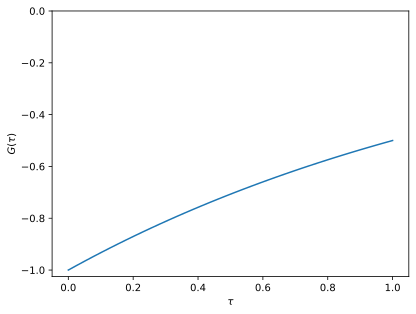

In [32]:
Gfunc = sp.lambdify([t, b], G)
plt.plot(tau, Gfunc(tau, beta))
plt.xlabel(r'$\tau$')
plt.ylabel(r'$G(\tau)$')
plt.ylim(top=0);

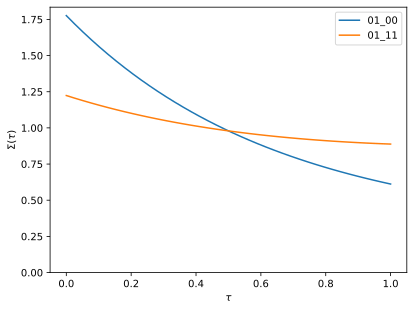

In [33]:
Sfunc_01_00 = sp.lambdify([t, b, w1, w2], Sigma_01_00)
Sfunc_01_11 = sp.lambdify([t, b, w1, w2], Sigma_01_11)

plt.plot(tau, Sfunc_01_00(tau, beta, omega1, omega2), label='01_00')
plt.plot(tau, Sfunc_01_11(tau, beta, omega1, omega2), label='01_11')

plt.legend(loc='best')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Sigma(\tau)$')
plt.ylim(bottom=0);

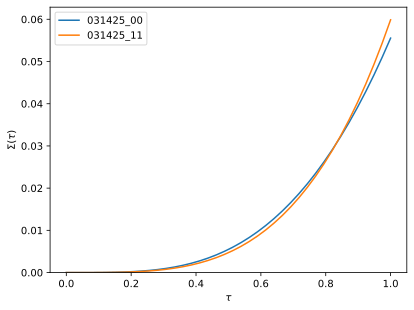

In [34]:
Sfunc_031425_00 = sp.lambdify([t, b], Sigma_031425_00.subs({w1: omega1, w2: omega2}))
Sfunc_031425_11 = sp.lambdify([t, b], Sigma_031425_11.subs({w1: omega1, w2: omega2}))

plt.plot(tau, Sfunc_031425_00(tau, beta), label='031425_00')
plt.plot(tau, Sfunc_031425_11(tau, beta), label='031425_11')

plt.legend(loc='best')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Sigma(\tau)$')
plt.ylim(bottom=0);

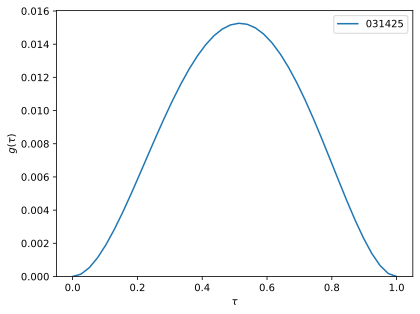

In [35]:
spgf_func_031425 = sp.lambdify([t, b], spgf_031425.subs({w1: omega1, w2: omega2}))

plt.plot(tau, spgf_func_031425(tau, beta), label='031425')

plt.legend(loc='best')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g(\tau)$')
plt.ylim(bottom=0);